# Preprocessing Experiments for CIFAR10-DVS

This notebook compares several event-to-frame configurations so we can choose a sensible baseline representation before training the SNN classifier.

## Goals

- compare multiple `n_time_bins` settings
- compare normalization on and off
- inspect tensor shapes, sparsity, and value ranges
- visualize how the same sample changes under different preprocessing choices

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve().parent
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

PROJECT_ROOT

PosixPath('/home/asen/Work/Uni Work/Година 3/Семестър 6/Невронни Мрежи/CourseProject')

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import torch

from snn_cifar10dvs.config import CIFAR10DVSConfig, ProjectPaths
from snn_cifar10dvs.data import load_cifar10dvs
from snn_cifar10dvs.preprocessing import FrameTransformConfig, build_frame_transform

paths = ProjectPaths()
dataset_config = CIFAR10DVSConfig()

## Experiment Configurations

In [3]:
experiment_configs = {
    "5_bins_norm": FrameTransformConfig(
        sensor_size=dataset_config.sensor_size,
        n_time_bins=5,
        normalize=True,
    ),
    "10_bins_norm": FrameTransformConfig(
        sensor_size=dataset_config.sensor_size,
        n_time_bins=10,
        normalize=True,
    ),
    "20_bins_norm": FrameTransformConfig(
        sensor_size=dataset_config.sensor_size,
        n_time_bins=20,
        normalize=True,
    ),
    "10_bins_no_norm": FrameTransformConfig(
        sensor_size=dataset_config.sensor_size,
        n_time_bins=10,
        normalize=False,
    ),
}

list(experiment_configs.keys())

['5_bins_norm', '10_bins_norm', '20_bins_norm', '10_bins_no_norm']

## Load a Reference Raw Sample

In [4]:
raw_dataset = load_cifar10dvs(paths=paths)
class_names = list(raw_dataset.classes)

sample_index = 0
raw_events, raw_target = raw_dataset[sample_index]
print("sample target:", raw_target, class_names[raw_target])
print("num raw events:", len(raw_events))

sample target: 0 airplane
num raw events: 210816


## Apply Multiple Preprocessing Variants

In [5]:
processed_samples = {}

for experiment_name, frame_config in experiment_configs.items():
    transform = build_frame_transform(frame_config)
    dataset = load_cifar10dvs(paths=paths, transform=transform)
    frames, target = dataset[sample_index]
    processed_samples[experiment_name] = {
        "frames": frames,
        "target": target,
        "shape": tuple(frames.shape),
        "min": float(frames.min()),
        "max": float(frames.max()),
        "mean": float(frames.mean()),
        "nonzero_fraction": float((frames > 0).float().mean()),
    }

processed_samples.keys()

dict_keys(['5_bins_norm', '10_bins_norm', '20_bins_norm', '10_bins_no_norm'])

In [6]:
summary_rows = []

for experiment_name, sample_info in processed_samples.items():
    summary_rows.append(
        {
            "experiment": experiment_name,
            "shape": sample_info["shape"],
            "min": sample_info["min"],
            "max": sample_info["max"],
            "mean": sample_info["mean"],
            "nonzero_fraction": sample_info["nonzero_fraction"],
        }
    )

summary_rows

[{'experiment': '5_bins_norm',
  'shape': (5, 2, 128, 128),
  'min': 0.0,
  'max': 1.0,
  'mean': 0.0612720362842083,
  'nonzero_fraction': 0.5014709234237671},
 {'experiment': '10_bins_norm',
  'shape': (10, 2, 128, 128),
  'min': 0.0,
  'max': 1.0,
  'mean': 0.03386085852980614,
  'nonzero_fraction': 0.33595579862594604},
 {'experiment': '20_bins_norm',
  'shape': (20, 2, 128, 128),
  'min': 0.0,
  'max': 1.0,
  'mean': 0.02010488510131836,
  'nonzero_fraction': 0.213725283741951},
 {'experiment': '10_bins_no_norm',
  'shape': (10, 2, 128, 128),
  'min': 0.0,
  'max': 19.0,
  'mean': 0.6433563232421875,
  'nonzero_fraction': 0.33595579862594604}]

## Visualization Helpers

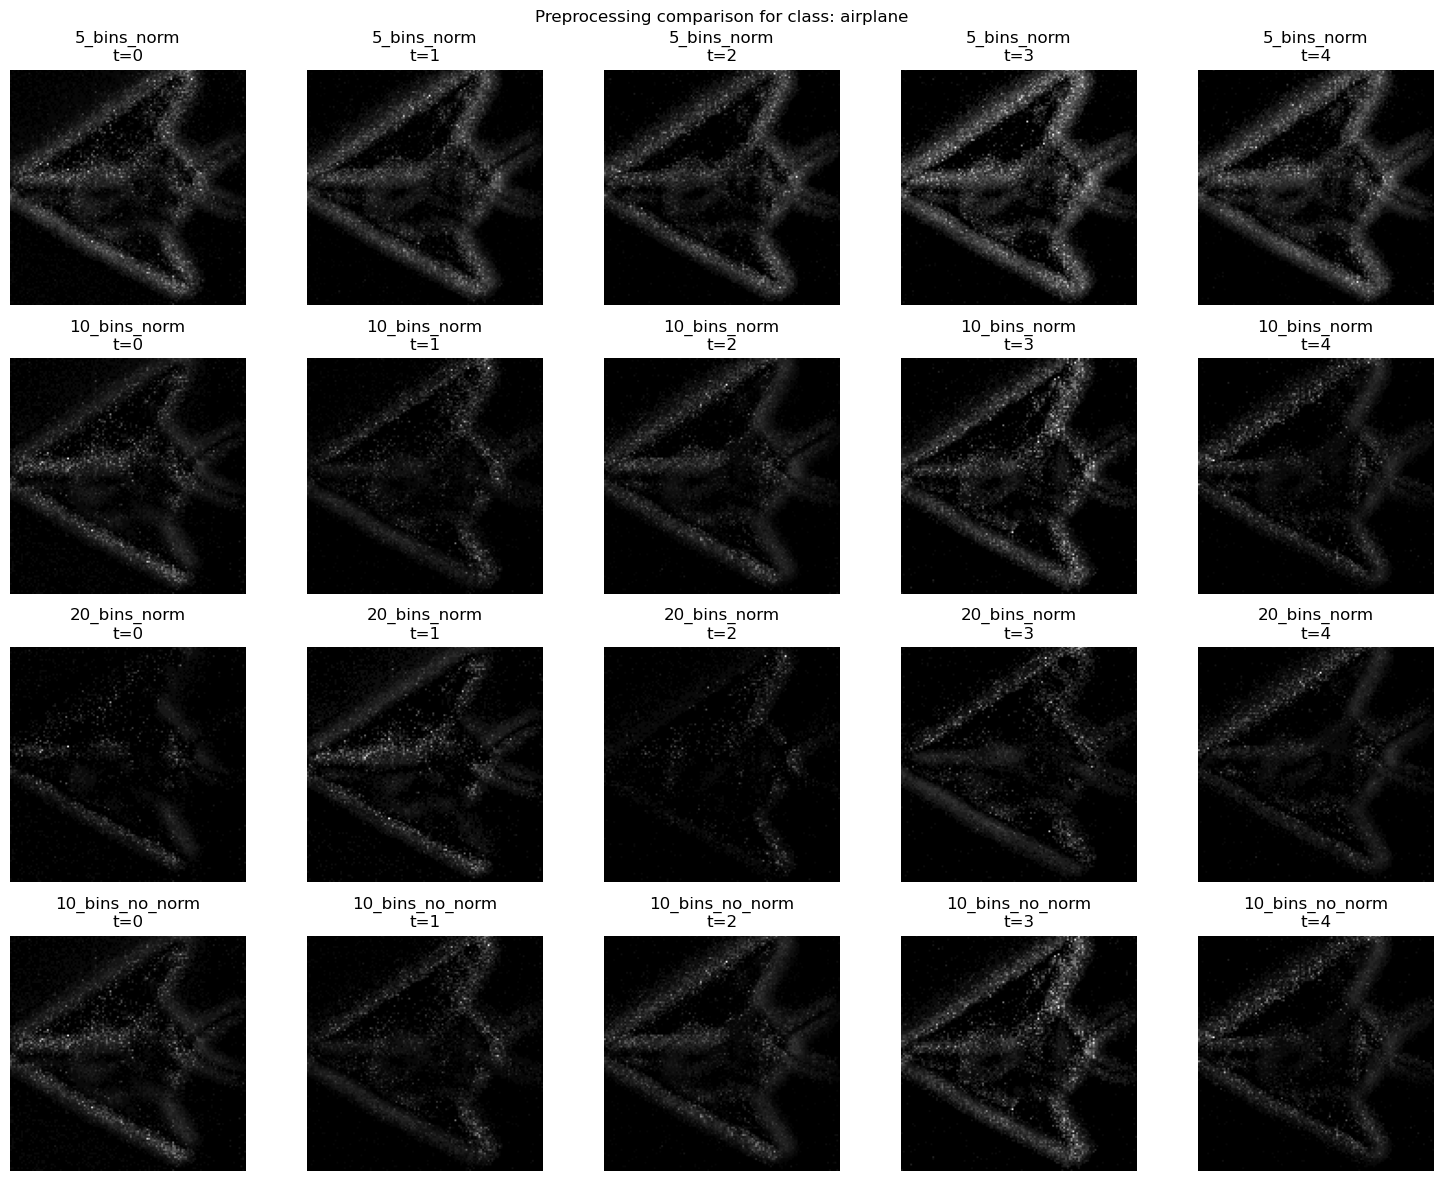

In [7]:
def show_experiment_frames(processed_samples_dict, class_name, max_time_steps=5):
    num_experiments = len(processed_samples_dict)
    figure, axes = plt.subplots(
        nrows=num_experiments,
        ncols=max_time_steps,
        figsize=(3 * max_time_steps, 3 * num_experiments),
        squeeze=False,
    )

    for row_index, (experiment_name, sample_info) in enumerate(processed_samples_dict.items()):
        frames = sample_info["frames"]
        time_steps = min(frames.shape[0], max_time_steps)
        merged_frames = frames.sum(dim=1)

        for column_index in range(max_time_steps):
            axis = axes[row_index][column_index]
            axis.axis("off")

            if column_index < time_steps:
                image = merged_frames[column_index].numpy()
                axis.imshow(image, cmap="gray")
                axis.set_title(f"{experiment_name}\nt={column_index}")

    figure.suptitle(f"Preprocessing comparison for class: {class_name}")
    figure.tight_layout()
    plt.show()


show_experiment_frames(processed_samples, class_names[raw_target])

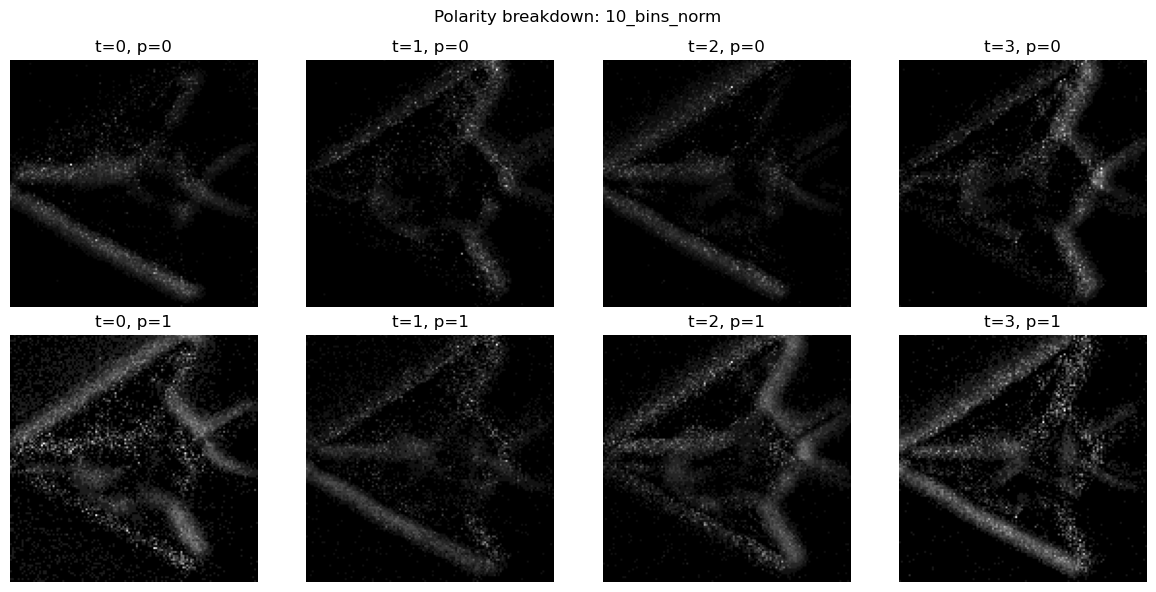

In [8]:
def show_polarity_breakdown(experiment_name, frames, max_time_steps=4):
    time_steps = min(frames.shape[0], max_time_steps)
    num_polarities = frames.shape[1]

    figure, axes = plt.subplots(
        nrows=num_polarities,
        ncols=time_steps,
        figsize=(3 * time_steps, 3 * num_polarities),
        squeeze=False,
    )

    for polarity_index in range(num_polarities):
        for time_index in range(time_steps):
            axis = axes[polarity_index][time_index]
            image = frames[time_index, polarity_index].numpy()
            axis.imshow(image, cmap="gray")
            axis.set_title(f"t={time_index}, p={polarity_index}")
            axis.axis("off")

    figure.suptitle(f"Polarity breakdown: {experiment_name}")
    figure.tight_layout()
    plt.show()


show_polarity_breakdown("10_bins_norm", processed_samples["10_bins_norm"]["frames"])

## Early Observations

- Fewer time bins usually produce denser, more aggregated frames.
- More time bins preserve temporal structure but often make each frame sparser.
- Normalization changes the numerical scale and may affect optimization stability during training.
- This notebook helps choose one baseline representation for the first training run.